In [1]:
from os.path import isfile, isdir, join
from os import listdir
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from plots import plot_box, plot_wortsman, extract_quantity_wortsman, DIVERGED

In [2]:
COLOR = plt.rcParams['axes.prop_cycle']
COLOR = [v for elem in list(COLOR) for _, v in elem.items()]
COLOR

['#0C5DA5', '#00B945', '#FF9500', '#FF2C00', '#845B97', '#474747', '#9e9e9e']

In [3]:
FIGURE_FORMAT = 'pdf'
# FIGURE_FORMAT = 'png'

In [4]:
LRS = [0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3]
MODEL_SIZES = ['4', '6', '8', 'A', 'C']
MODEL_SIZES_LABELS = [r'$16M$', r'$29M$', r'$57M$', r'$109M$', r'$221M$']

In [5]:
# PARAMETERS
WEIGHT_TYING = True
VARIANT_ANALYSIS = 'a' if WEIGHT_TYING is True else 'A'

WT = '.WT' if WEIGHT_TYING else ''

In [6]:
path_stats = './stats'
assert isdir(path_stats)

# 1. Load Data

In [7]:
runs = {}
for elem in listdir(path_stats):
    if elem.startswith('wor'):
        path_subdirectory = join(path_stats, elem)
        if isdir(path_subdirectory):
            model_size = elem[3]
            lr = float(int(elem.split('-')[5][2:])) / 10**4
            label = (model_size, lr)
            runs[label] = elem 
runs = dict(sorted(runs.items()))
runs

{('4', 0.0003): 'wor40a-16M-13p1B-100k-bs64-lr3-baselinewt-g0e+00-s1',
 ('4', 0.001): 'wor40a-16M-13p1B-100k-bs64-lr10-baselinewt-g0e+00-s1',
 ('4', 0.003): 'wor40a-16M-13p1B-100k-bs64-lr30-baselinewt-g0e+00-s1',
 ('4', 0.01): 'wor40a-16M-13p1B-100k-bs64-lr100-baselinewt-g0e+00-s1',
 ('4', 0.03): 'wor40a-16M-13p1B-100k-bs64-lr300-baselinewt-g0e+00-s1',
 ('4', 0.1): 'wor40a-16M-13p1B-100k-bs64-lr1000-baselinewt-g0e+00-s1',
 ('4', 0.3): 'wor40a-16M-13p1B-100k-bs64-lr3000-baselinewt-g0e+00-s1',
 ('6', 0.0003): 'wor60a-29M-13p1B-100k-bs64-lr3-baselinewt-g0e+00-s1',
 ('6', 0.001): 'wor60a-29M-13p1B-100k-bs64-lr10-baselinewt-g0e+00-s1',
 ('6', 0.003): 'wor60a-29M-13p1B-100k-bs64-lr30-baselinewt-g0e+00-s1',
 ('6', 0.01): 'wor60a-29M-13p1B-100k-bs64-lr100-baselinewt-g0e+00-s1',
 ('6', 0.03): 'wor60a-29M-13p1B-100k-bs64-lr300-baselinewt-g0e+00-s1',
 ('6', 0.1): 'wor60a-29M-13p1B-100k-bs64-lr1000-baselinewt-g0e+00-s1',
 ('6', 0.3): 'wor60a-29M-13p1B-100k-bs64-lr3000-baselinewt-g0e+00-s1',
 ('8',

In [8]:
MU_NORM = {
    '4': [1.435, 2.212, 5.806, 20.212, 56.652, 187.225, 331.471],
    '6': [1.331, 2.137, 5.885, 19.942, 63.188, 192.094, 321.511],
    '8': [1.114, 1.865, 6.368, 18.563, 79.721, 144.418, 359.24],
    'A': [1.167, 2.4, 8.126, 19.849, 72.207, 146.293, 467.2],
    'C': [1.204, 2.337, 5.625, 20.019, 75.824, 209.223, 446.517],
}

LR_IDX = {
    0.0003: 0,
    0.001: 1,
    0.003: 2,
    0.01: 3,
    0.03: 4,
    0.1: 5,
    0.3: 6,
}

def mu_norm(_input):
    _model_size, _lr = _input
    lr_idx = LR_IDX[_lr]
    return MU_NORM[_model_size][lr_idx]

def h_norm(_input):
    lgt_mean, lgt_mean_cos, mu_norm = _input
    h_mean = lgt_mean / (mu_norm * lgt_mean_cos)
    return h_mean

def product(_input):
    lgt_mean, B_ratio = _input
    return lgt_mean * B_ratio

def ratio(_input):
    a, b = _input
    return a / b

In [9]:
QUANTITIES = [
    'B_ratio_nominator',
    'B_ratio_denominator',
    'B_ratio',
    'lgt_min',
    'lgt_max',
    'lgt_mean',
    'lgt_mean_cos',
    'c',
    'c_star',
]

def load_data(_label, _path):
    complete_path_dir = join(path_stats, _path)
    assert isdir(complete_path_dir)
    _data = {}
    _dfs = []
    for quantity in QUANTITIES:
        complete_path_quantity = join(complete_path_dir, f'ckpt_100000.pt.{quantity}.npy')
        assert isfile(complete_path_quantity)
        array = np.load(complete_path_quantity)
        if quantity == 'B_ratio':
            print(f'{_label}: shape={array.shape}, min={np.min(array):.3f}, mean={np.mean(array):.3f}, max={np.max(array):.3f}')
        _data[quantity] = array
    _df = pd.DataFrame(_data)
    _df['lgt_mean_cos_abs'] = _df['lgt_mean_cos'].abs()
    _df['model_size'] = _label[0]
    _df['lr'] = float(_label[1])
    _df['mu_norm'] = _df[['model_size', 'lr']].apply(lambda x: mu_norm(x), axis=1)
    _df['h_norm'] = _df[['lgt_mean', 'lgt_mean_cos', 'mu_norm']].apply(lambda x: h_norm(x), axis=1)
    _df['product'] = _df[['lgt_mean', 'B_ratio']].apply(lambda x: product(x), axis=1)
    _df['B_ratio_inverse'] = _df['B_ratio'].pow(-1)
    _df['c_ratio'] = _df[['c_star', 'c']].apply(lambda x: ratio(x), axis=1)
    _dfs.append(_df)
    _df_all = pd.concat(_dfs)
    return _df_all
    

In [10]:
df = {label: load_data(label, path) for label, path in runs.items()}
df

('4', 0.0003): shape=(131072,), min=0.334, mean=0.891, max=1.439
('4', 0.001): shape=(131072,), min=0.274, mean=0.811, max=1.351
('4', 0.003): shape=(131072,), min=0.226, mean=0.738, max=1.339
('4', 0.01): shape=(131072,), min=0.223, mean=0.577, max=1.495
('4', 0.03): shape=(131072,), min=0.109, mean=0.329, max=1.311
('4', 0.1): shape=(131072,), min=0.046, mean=0.118, max=1.229
('4', 0.3): shape=(131072,), min=0.074, mean=0.197, max=1.255
('6', 0.0003): shape=(131072,), min=0.340, mean=0.936, max=1.460
('6', 0.001): shape=(131072,), min=0.329, mean=0.912, max=1.397
('6', 0.003): shape=(131072,), min=0.347, mean=0.837, max=1.381
('6', 0.01): shape=(131072,), min=0.293, mean=0.799, max=1.346
('6', 0.03): shape=(131072,), min=0.224, mean=0.695, max=1.288
('6', 0.1): shape=(131072,), min=0.064, mean=0.181, max=1.180
('6', 0.3): shape=(131072,), min=0.033, mean=0.072, max=1.218
('8', 0.0003): shape=(131072,), min=0.342, mean=0.972, max=1.491
('8', 0.001): shape=(131072,), min=0.275, mean=0.

{('4',
  0.0003):         B_ratio_nominator  B_ratio_denominator   B_ratio    lgt_min  \
 0               10.658711              17.7500  0.600491 -17.750000   
 1               12.230345              16.7500  0.730170 -16.750000   
 2                9.317516              17.0000  0.548089   0.582031   
 3               11.135799              19.2500  0.578483 -19.250000   
 4               13.088277              20.7500  0.630760  -4.750000   
 ...                   ...                  ...       ...        ...   
 131067          14.473856              15.5625  0.930047 -15.562500   
 131068          14.342375              16.8750  0.849918 -10.875000   
 131069          13.644745              18.7500  0.727720 -18.750000   
 131070          12.348127              15.4375  0.799879 -15.437500   
 131071          17.350531              14.6250  1.186361 -14.625000   
 
           lgt_max   lgt_mean  lgt_mean_cos         c    c_star  \
 0       -1.929688 -12.588399     -0.126946  0.107

# 2. Grid Plots

In [11]:
df_all = pd.concat(list(df.values()), ignore_index=True)
df_all

,B_ratio_nominator,B_ratio_denominator,B_ratio,lgt_min,lgt_max,lgt_mean,lgt_mean_cos,c,c_star,lgt_mean_cos_abs,model_size,lr,mu_norm,h_norm,product,B_ratio_inverse,c_ratio
0,10.658711,17.75,0.600491,-17.750000,-1.929688,-12.588399,-0.126946,0.107622,0.049392,0.126946,4,0.0003,1.435,69.103465,-7.559218,1.665304,0.458938
1,12.230345,16.75,0.730170,-16.750000,3.234375,-8.995970,-0.089651,0.113520,0.056008,0.089651,4,0.0003,1.435,69.926507,-6.568586,1.369544,0.493371
2,9.317516,17.00,0.548089,0.582031,17.000000,7.682483,0.073210,0.179254,0.066613,0.073210,4,0.0003,1.435,73.127566,4.210686,1.824521,0.371614
3,11.135799,19.25,0.578483,-19.250000,0.069824,-11.065975,-0.107401,0.121046,0.046748,0.107401,4,0.0003,1.435,71.800552,-6.401480,1.728659,0.386203
4,13.088277,20.75,0.630760,-4.750000,20.750000,7.661723,0.063701,0.160693,0.160971,0.063701,4,0.0003,1.435,83.816652,4.832711,1.585388,1.001734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4587515,85.543335,1888.00,0.045309,1776.000000,1888.000000,1861.543335,0.180583,0.187176,0.008554,0.180583,C,0.3000,446.517,23.086518,84.344611,22.070685,0.045703
4587516,89.053833,1872.00,0.047571,1760.000000,1872.000000,1849.053833,0.179898,0.226482,0.008932,0.179898,C,0.3000,446.517,23.018930,87.962249,21.020993,0.039437
4587517,49.202148,1280.00,0.038439,1200.000000,1280.000000,1249.202148,0.181840,0.231696,0.007682,0.181840,C,0.3000,446.517,15.385285,48.018302,26.015125,0.033155
4587518,84.403564,1880.00,0.044896,1776.000000,1880.000000,1860.403564,0.180539,0.181088,0.008785,0.180539,C,0.3000,446.517,23.077993,83.523776,22.273940,0.048514


In [12]:
df_all.describe()

,B_ratio_nominator,B_ratio_denominator,B_ratio,lgt_min,lgt_max,lgt_mean,lgt_mean_cos,c,c_star,lgt_mean_cos_abs,lr,mu_norm,h_norm,product,B_ratio_inverse,c_ratio
count,4.587520e+06,4.587520e+06,4.587520e+06,4.587520e+06,4.587520e+06,4.587520e+06,4.587520e+06,4.587520e+06,4.587520e+06,4.587520e+06,4.587520e+06,4.587520e+06,4.587520e+06,4.587520e+06,4.587520e+06,4.587520e+06
mean,2.333750e+01,1.882283e+02,5.785816e-01,1.462838e+02,1.843016e+02,1.666928e+02,5.112240e-02,1.223670e-01,5.575305e-02,8.133500e-02,6.347143e-02,9.429660e+01,3.517077e+01,1.085249e+01,4.888690e+00,6.365840e-01
std,1.771365e+01,4.436482e+02,3.617253e-01,4.276209e+02,4.451654e+02,4.434352e+02,1.002670e-01,7.231529e-02,4.647253e-02,7.779195e-02,1.019872e-01,1.345283e+02,3.043117e+01,2.237950e+01,6.977841e+00,5.511987e-01
min,7.101077e+00,7.375000e+00,2.367558e-02,-6.720000e+02,-1.950000e+02,-3.353781e+02,-2.373637e-01,9.733813e-03,3.178133e-03,5.005859e-09,3.000000e-04,1.114000e+00,4.687002e-01,-1.485853e+02,6.687667e-01,1.646805e-02
25%,1.535118e+01,1.875000e+01,2.217457e-01,-1.600000e+01,1.218750e+01,-3.956250e+00,-2.278178e-02,6.879202e-02,2.338978e-02,2.400849e-02,1.000000e-03,2.337000e+00,8.524585e+00,-3.897265e+00,1.131062e+00,1.857450e-01
50%,1.746561e+01,2.775000e+01,6.230737e-01,-7.125000e+00,2.487500e+01,7.054734e+00,2.524184e-02,1.022916e-01,4.422223e-02,5.244905e-02,1.000000e-02,1.994200e+01,2.313535e+01,5.097175e+00,1.604947e+00,5.278092e-01
75%,2.103077e+01,9.900000e+01,8.841246e-01,6.325000e+01,9.900000e+01,8.093354e+01,1.198118e-01,1.647707e-01,7.421550e-02,1.215133e-01,1.000000e-01,1.462930e+02,6.233962e+01,1.464770e+01,4.509671e+00,9.232575e-01
max,8.187935e+02,2.304000e+03,1.495290e+00,2.160000e+03,2.304000e+03,2.249349e+03,4.446432e-01,5.304262e-01,4.938471e-01,4.446432e-01,3.000000e-01,4.672000e+02,1.515602e+02,4.132382e+02,4.223762e+01,6.295975e+00


In [13]:
131072 * 7 * 5

4587520

# 3. Percentages

In [14]:
QUANTITIES_SPECIAL = ['B_ratio', 'lgt_mean_cos', 'lgt_mean', 'c', 'c_star', 'c_ratio']

In [15]:
percentage = {k: {} for k in QUANTITIES_SPECIAL}
for label, _df in df.items():
    _df['percentage_B_ratio'] = _df['B_ratio'].apply(lambda x: x < 1)
    _df['percentage_lgt_mean'] = _df['lgt_mean'].apply(lambda x: x > 0)
    _df['percentage_lgt_mean_cos'] = _df['lgt_mean_cos'].apply(lambda x: x > 0)
    _df['percentage_c'] = _df['c'].apply(lambda x: x < 0.1)
    _df['percentage_c_star'] = _df['c_star'].apply(lambda x: x < 0.1)
    _df['percentage_c_ratio'] = _df['c_ratio'].apply(lambda x: x < 1)
    percentage['B_ratio'][label] = float(_df['percentage_B_ratio'].mean())
    percentage['lgt_mean'][label] = float(_df['percentage_lgt_mean'].mean())
    percentage['lgt_mean_cos'][label] = float(_df['percentage_lgt_mean_cos'].mean())
    percentage['c'][label] = float(_df['percentage_c'].mean())
    percentage['c_star'][label] = float(_df['percentage_c_star'].mean())
    percentage['c_ratio'][label] = float(_df['percentage_c_ratio'].mean())

percentage

{'B_ratio': {('4', 0.0003): 0.6960678100585938,
  ('4', 0.001): 0.8235092163085938,
  ('4', 0.003): 0.8930587768554688,
  ('4', 0.01): 0.9441680908203125,
  ('4', 0.03): 0.9917373657226562,
  ('4', 0.1): 0.9984512329101562,
  ('4', 0.3): 0.9989471435546875,
  ('6', 0.0003): 0.58843994140625,
  ('6', 0.001): 0.6756515502929688,
  ('6', 0.003): 0.864898681640625,
  ('6', 0.01): 0.8478775024414062,
  ('6', 0.03): 0.9248580932617188,
  ('6', 0.1): 0.9993209838867188,
  ('6', 0.3): 0.9999618530273438,
  ('8', 0.0003): 0.55621337890625,
  ('8', 0.001): 0.8314208984375,
  ('8', 0.003): 0.9107437133789062,
  ('8', 0.01): 0.9287796020507812,
  ('8', 0.03): 0.980682373046875,
  ('8', 0.1): 0.9786300659179688,
  ('8', 0.3): 0.9999008178710938,
  ('A', 0.0003): 0.498748779296875,
  ('A', 0.001): 0.7645645141601562,
  ('A', 0.003): 0.9054183959960938,
  ('A', 0.01): 0.9691696166992188,
  ('A', 0.03): 0.9756546020507812,
  ('A', 0.1): 0.9988784790039062,
  ('A', 0.3): 0.9999542236328125,
  ('C', 0.0

In [16]:
def plot_percentage(quantity, ylabel):
    fig, ax = plt.subplots(1, 1, figsize=(6,4))
    ax = [ax, None]
    percentage_quantity = {
        model_size: [percentage[quantity][(model_size, lr)] for lr in LRS]
        for model_size in MODEL_SIZES
    }
    for model_size in MODEL_SIZES:
        ax[0].plot(LRS, percentage_quantity[model_size], linestyle='--', marker='o', color=CLR)
    
    _ = ax[0].set_xlabel(r'$\eta$')
    _ = ax[0].set_ylabel(ylabel)
    _ = ax[0].set_ylim([0, 1])
    # _ = ax[0].set_xticks(LRS)
    # _ = ax[0].set_xticklabels(LRS)
    _ = ax[0].set_xscale("log")

# 4. Box Plots

> saved as figs/stats.B_ratio.WT.pdf


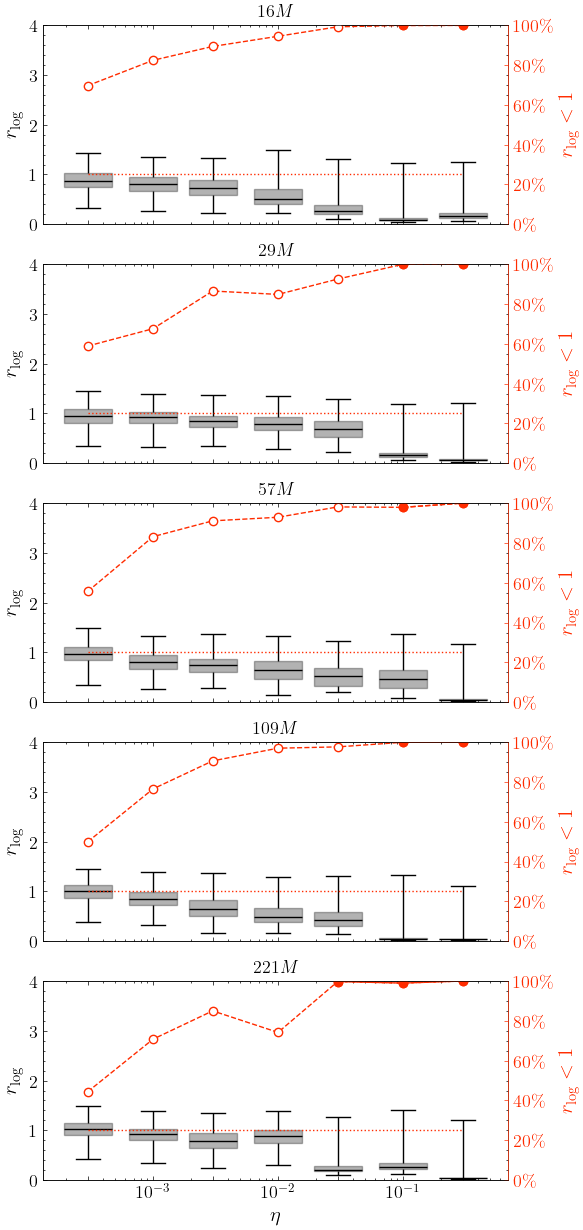

In [17]:
plot_box(
    LRS,
    'B_ratio', 
    percentage,
    MODEL_SIZES, 
    MODEL_SIZES_LABELS, 
    r'$r_{\rm log}$', 
    r'$r_{\rm log} < 1$', 
    df_all,
    diverged=DIVERGED[VARIANT_ANALYSIS],
    save_as=f'stats.B_ratio{WT}.{FIGURE_FORMAT}',
)

> saved as figs/stats.lgt_mean.WT.pdf


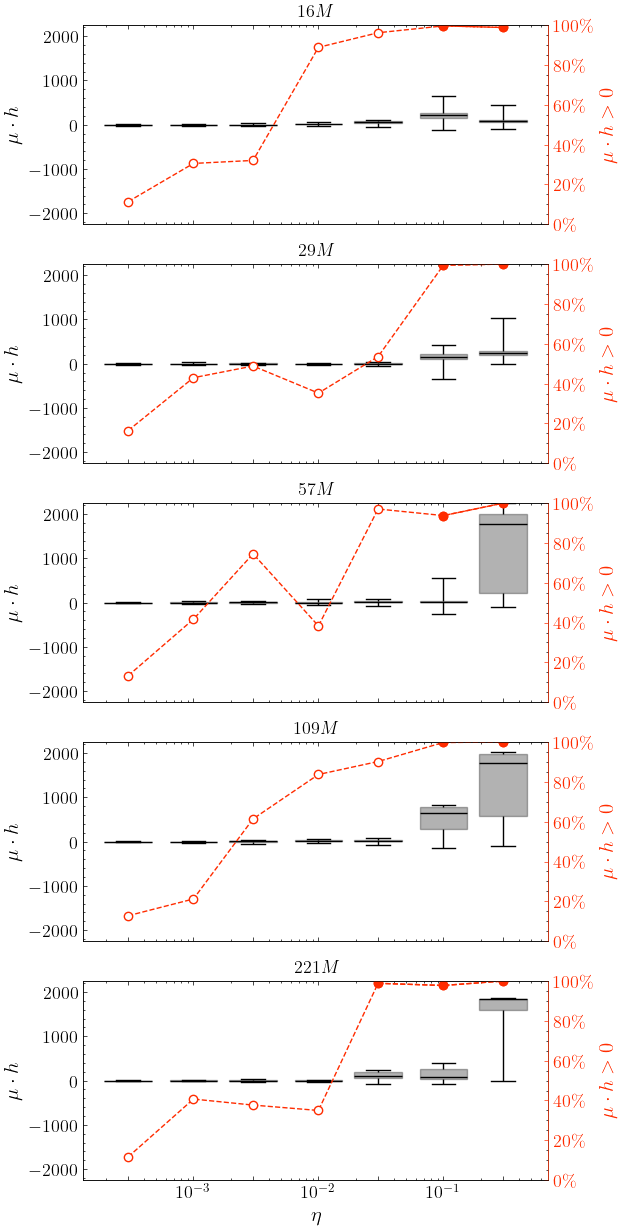

In [18]:
plot_box(
    LRS,
    'lgt_mean', 
    percentage,
    MODEL_SIZES, 
    MODEL_SIZES_LABELS, 
    r'$\mu \cdot h$', 
    r'$\mu \cdot h > 0$', 
    df_all,
    diverged=DIVERGED[VARIANT_ANALYSIS],
    save_as=f'stats.lgt_mean{WT}.{FIGURE_FORMAT}',
)

> saved as figs/stats.lgt_mean_cos.WT.pdf


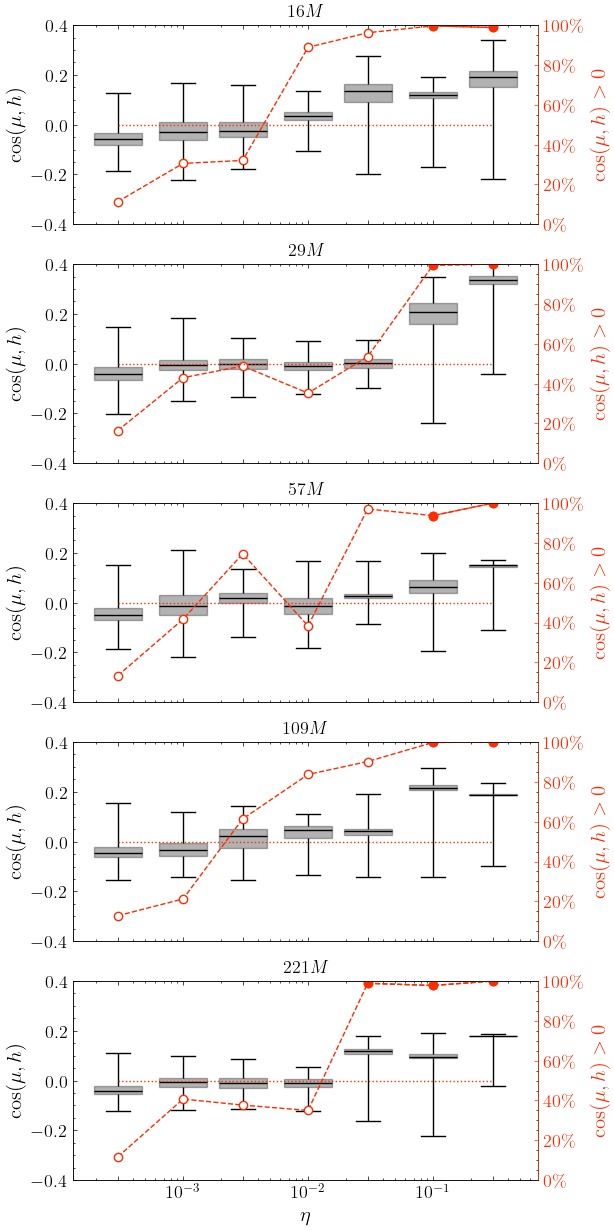

In [19]:
plot_box(
    LRS,
    'lgt_mean_cos',
    percentage,
    MODEL_SIZES, 
    MODEL_SIZES_LABELS, 
    r'$\cos(\mu, h)$', 
    r'$\cos(\mu, h) > 0$', 
    df_all,
    diverged=DIVERGED[VARIANT_ANALYSIS],
    save_as=f'stats.lgt_mean_cos{WT}.{FIGURE_FORMAT}',
)

> saved as figs/stats.c.WT.pdf


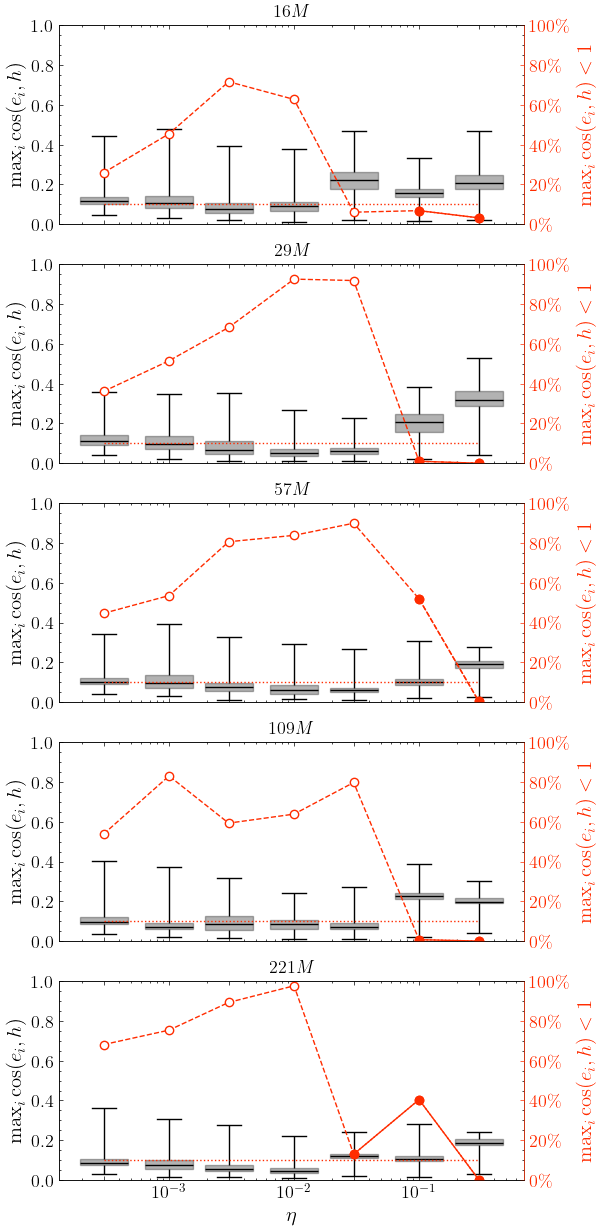

In [20]:
plot_box(
    LRS,
    'c', 
    percentage,
    MODEL_SIZES, 
    MODEL_SIZES_LABELS, 
    r'$\max_i {\rm cos}(e_i, h)$', 
    r'$\max_i {\rm cos}(e_i, h) < 1$', 
    df_all,
    diverged=DIVERGED[VARIANT_ANALYSIS],
    save_as=f'stats.c{WT}.{FIGURE_FORMAT}',
)

> saved as figs/stats.c_star.WT.pdf


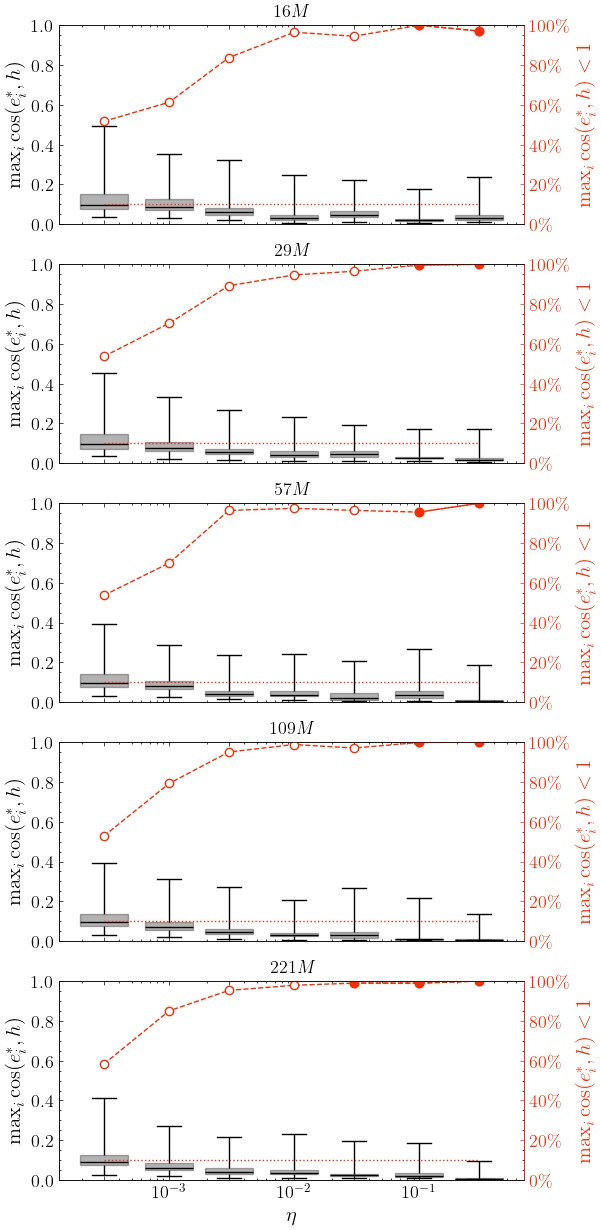

In [21]:
plot_box(
    LRS,
    'c_star', 
    percentage,
    MODEL_SIZES, 
    MODEL_SIZES_LABELS, 
    r'$\max_i {\rm cos}(e_i^*, h)$', 
    r'$\max_i {\rm cos}(e_i^*, h) < 1$', 
    df_all,
    diverged=DIVERGED[VARIANT_ANALYSIS],
    save_as=f'stats.c_star{WT}.{FIGURE_FORMAT}',
)

> saved as figs/stats.c_ratio.WT.pdf


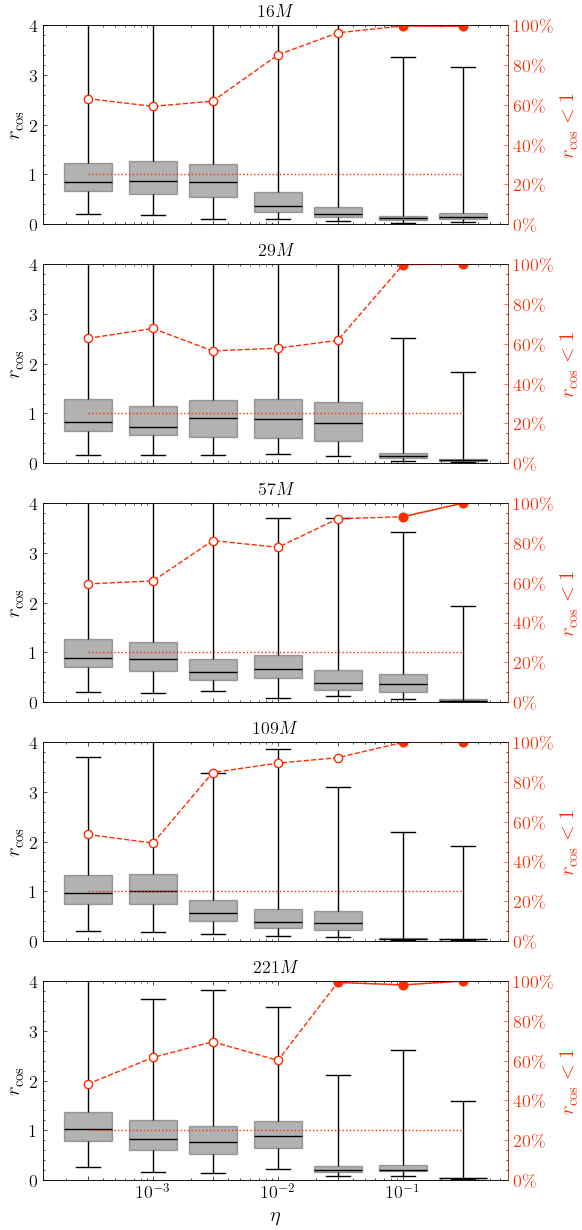

In [22]:
plot_box(
    LRS,
    'c_ratio', 
    percentage,
    MODEL_SIZES, 
    MODEL_SIZES_LABELS, 
    r'$r_{\rm cos}$', 
    r'$r_{\rm cos} < 1$', 
    df_all,
    diverged=DIVERGED[VARIANT_ANALYSIS],
    save_as=f'stats.c_ratio{WT}.{FIGURE_FORMAT}',
)

# 5. Wortsman Plots

In [23]:
NS = ['4', '6', '8', 'A', 'C']

#### r_log

In [24]:
r_log = extract_quantity_wortsman(df_all, LRS, "B_ratio", VARIANT_ANALYSIS, lr_integer=False)
r_log

{'4': {'a': {0.0: [0.8910739631903652,
    0.8112304705164206,
    0.7379311068581274,
    0.5774857721310127,
    0.3286739718848821,
    0.11798489301608583,
    0.1969823333706131]}},
 '6': {'a': {0.0: [0.9356988184481452,
    0.9122841847024574,
    0.836713821152216,
    0.7988921009002752,
    0.6945677817698197,
    0.18067155965115944,
    0.07204834123982096]}},
 '8': {'a': {0.0: [0.9719229953545891,
    0.8124709093158344,
    0.7439235324832225,
    0.6475233314180286,
    0.5346199413339718,
    0.4790480624147335,
    0.06916023125928916]}},
 'A': {'a': {0.0: [0.9905091414773324,
    0.8632687687813814,
    0.6828535104313005,
    0.5418249121166809,
    0.4713770278320908,
    0.0730489585155425,
    0.0517976166497931]}},
 'C': {'a': {0.0: [1.0206511550397863,
    0.9077240351762157,
    0.7856689205009388,
    0.8736772338977516,
    0.26134052675115527,
    0.32538561009869227,
    0.05031986220464546]}}}

> saved as figs/stats.wortsman.B_ratio.WT.pdf


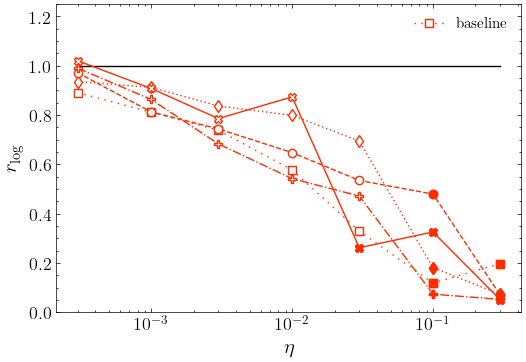

In [25]:
plot_wortsman(LRS, r_log, 'r_log', ns=NS, variants_lambdas={VARIANT_ANALYSIS: [0.0]}, ylim=[0, 1.25], legend=True, line=1, diverged=DIVERGED, save_as=f'stats.wortsman.B_ratio{WT}.{FIGURE_FORMAT}')

#### cos(mu, h)

In [26]:
cos_mu_h = extract_quantity_wortsman(df_all, LRS, "lgt_mean_cos", VARIANT_ANALYSIS, lr_integer=False)
cos_mu_h

{'4': {'a': {0.0: [-0.053777482303448365,
    -0.02351893741134592,
    -0.016262491769347576,
    0.03251126785520175,
    0.1229192827635972,
    0.116349219073701,
    0.18027121852740974]}},
 '6': {'a': {0.0: [-0.03711951626346721,
    -0.0038334879724875037,
    -0.0018620432838235557,
    -0.008921644054243338,
    0.00020872016925044257,
    0.20300897851054245,
    0.33552939184207276]}},
 '8': {'a': {0.0: [-0.04182192727560913,
    -0.004999534161709729,
    0.017298442847878737,
    -0.011257178145204036,
    0.027982534074687954,
    0.05871548275197108,
    0.14716231419292658]}},
 'A': {'a': {0.0: [-0.03758579168742182,
    -0.029588357690055078,
    0.013606353111411451,
    0.03609966170529699,
    0.04039196590777416,
    0.21398599438590082,
    0.18947213353936299]}},
 'C': {'a': {0.0: [-0.034327796036683234,
    -0.006581756355484636,
    -0.00799392547580191,
    -0.010317195121040568,
    0.11208941665501859,
    0.09313751993608355,
    0.1783131774230613]}}}

> saved as figs/stats.wortsman.lgt_mean_cos.WT.pdf


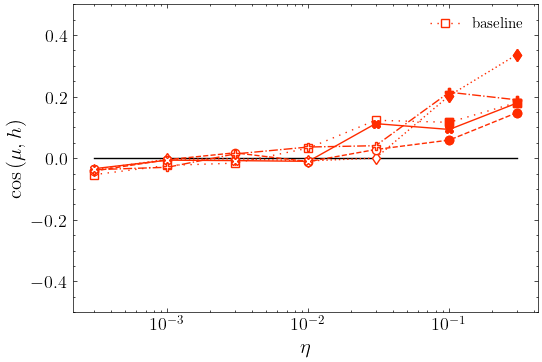

In [27]:
plot_wortsman(LRS, cos_mu_h, 'cos_mu_h', ns=NS, variants_lambdas={VARIANT_ANALYSIS: [0.0]}, ylim=[-0.5, 0.5], legend=True, line=0, diverged=DIVERGED, save_as=f'stats.wortsman.lgt_mean_cos{WT}.{FIGURE_FORMAT}')

#### r_cos

In [28]:
r_cos = extract_quantity_wortsman(df_all, LRS, "c_ratio", VARIANT_ANALYSIS, lr_integer=False)
r_cos

{'4': {'a': {0.0: [1.0462262468119656,
    1.0114195676231912,
    0.9556501983102574,
    0.552290269370495,
    0.3088965223794593,
    0.15232111678005805,
    0.19374201677789]}},
 '6': {'a': {0.0: [1.0405250865304856,
    0.9373223918343156,
    0.9785802611829326,
    0.9812733727982995,
    0.8961334074924784,
    0.16793087675475846,
    0.06980391172467147]}},
 '8': {'a': {0.0: [1.0548126095836476,
    0.9735266281663303,
    0.7198486427721755,
    0.7639412728910291,
    0.494479486710172,
    0.441902641175451,
    0.06202863981617502]}},
 'A': {'a': {0.0: [1.0921398236925217,
    1.0966843657319991,
    0.6602508539322953,
    0.5146718974793941,
    0.4673968225853026,
    0.0753763705512732,
    0.054134590606308354]}},
 'C': {'a': {0.0: [1.1283825369099356,
    0.9696694451572417,
    0.8622996307747205,
    0.9546526612848253,
    0.26089598891100296,
    0.2903038150170862,
    0.05092615530539697]}}}

> saved as figs/stats.wortsman.c_ratio.WT.pdf


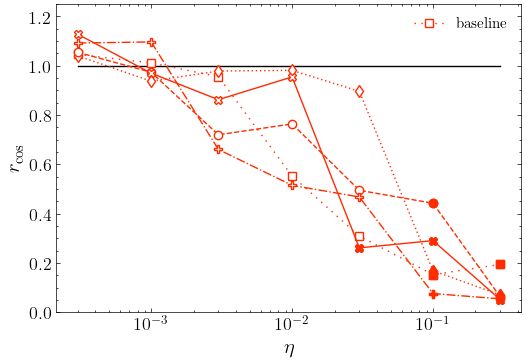

In [29]:
plot_wortsman(LRS, r_cos, 'r_cos', ns=NS, variants_lambdas={VARIANT_ANALYSIS: [0.0]}, ylim=[0, 1.25], legend=True, line=1, diverged=DIVERGED, save_as=f'stats.wortsman.c_ratio{WT}.{FIGURE_FORMAT}')

# 6. Correlations

### B_ratio

In [30]:
def scatterplot(_df, _x, _y, save_as=''):
    _ = sns.scatterplot(_df, x=_x, y=_y, color=CLR)
    
    if len(save_as):
        assert save_as.endswith('.pdf') or save_as.endswith('.png')
        fig_path = f'figs/{save_as}'
        plt.savefig(fig_path, format=save_as[-3:], bbox_inches='tight')
        print(f'> saved as {fig_path}')

### c_ratio = c_star / c

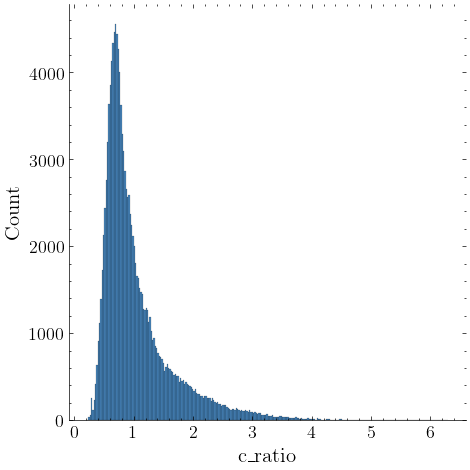

In [31]:
_ = sns.displot(
    df[('4', 0.0003)]["c_ratio"], 
    # save_as=f'stats.correlation_lgt_mean_cos_abs_B_ratio{WT}.{FIGURE_FORMAT}'
)